# Preparação dos dados - Dataset Adverse Events Drugs API Open FDA

In [4]:
import pandas as pd
import json

In [9]:
with open('../datasets/drug-event-0001-of-0028-2025-q1.json', "r", encoding="utf-8") as f:
    data = json.load(f)
df = pd.json_normalize(data["results"])
df.head()

,safetyreportversion,safetyreportid,primarysourcecountry,occurcountry,transmissiondateformat,transmissiondate,reporttype,serious,seriousnessdeath,seriousnesslifethreatening,...,patient.patientonsetageunit,patient.patientsex,patient.reaction,patient.drug,reportduplicate,patient.summary.narrativeincludeclinical,patient.patientagegroup,authoritynumb,patient.patientweight,primarysource.literaturereference
0,1,24916426,NZ,NZ,102,20250409,1,1,2,2,...,801,2,"[{'reactionmeddraversionpt': '27.1', 'reaction...","[{'drugcharacterization': '1', 'medicinalprodu...",NaN,NaN,NaN,NaN,NaN,NaN
1,1,24917560,CA,CA,102,20250409,2,1,2,2,...,NaN,NaN,"[{'reactionmeddraversionpt': '27.1', 'reaction...","[{'drugcharacterization': '1', 'medicinalprodu...","[{'duplicatesource': 'ENDO OPERATIONS LTD.', '...",CASE EVENT DATE: 20240624,NaN,NaN,NaN,NaN
2,1,24917803,US,US,102,20250408,1,2,2,2,...,801,1,"[{'reactionmeddraversionpt': '27.1', 'reaction...","[{'drugcharacterization': '1', 'medicinalprodu...",NaN,CASE EVENT DATE: 20250130,5,NaN,NaN,NaN
3,1,24917951,US,NaN,102,20250409,1,2,2,2,...,NaN,NaN,"[{'reactionmeddraversionpt': '27.1', 'reaction...","[{'drugcharacterization': '1', 'medicinalprodu...",NaN,NaN,NaN,738799,NaN,NaN
4,1,24920814,FR,FR,102,20250409,1,1,NaN,NaN,...,801,1,"[{'reactionmeddraversionpt': '27.1', 'reaction...","[{'drugcharacterization': '1', 'medicinalprodu...",NaN,CASE EVENT DATE: 20250103,5,FR-AFSSAPS-BX2025000068,40,NaN


In [13]:
reports = pd.json_normalize(data["results"])

drugs = pd.json_normalize(
    data["results"],
    record_path=["patient", "drug"],
    meta=["safetyreportid", "receivedate"],
    errors="ignore"
)

reactions = pd.json_normalize(
    data["results"],
    record_path=["patient", "reaction"],
    meta=["safetyreportid", "receivedate"],
    errors="ignore"
)

print(reports.shape)
print(drugs.shape)
print(reactions.shape)

(12000, 40)
(48861, 45)
(36247, 5)


<Axes: xlabel='reactionmeddrapt'>

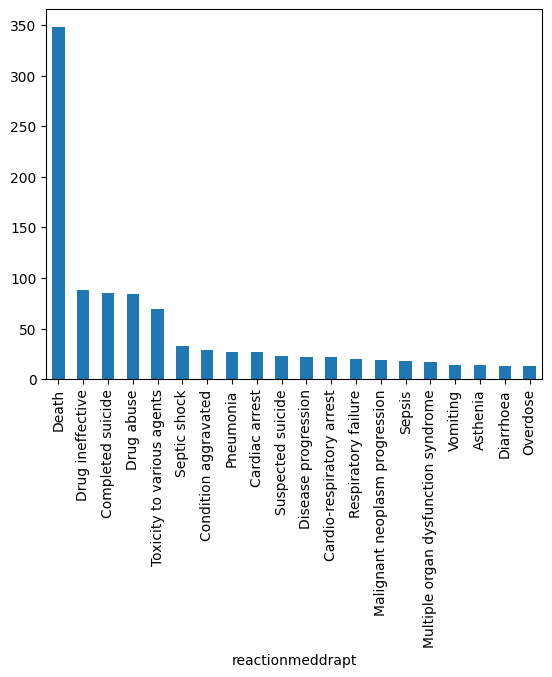

In [33]:
reactions[reactions['reactionoutcome'] == '5']['reactionmeddrapt'].value_counts().head(20).plot.bar()